In [1]:
# Importar librerías
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.experimental import enable_hist_gradient_boosting
from sklearn.ensemble import HistGradientBoostingClassifier

/usr/local/lib/python3.9/dist-packages/sklearn/experimental/enable_hist_gradient_boosting.py:16: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
pd.options.display.max_columns = None

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer, roc_auc_score, f1_score, recall_score, precision_score, accuracy_score, roc_curve, auc
scoring = {'accuracy': 'accuracy', 
           'roc_auc': make_scorer(roc_auc_score), 
           'f1': make_scorer(f1_score),
           'recall': make_scorer(recall_score), 
           'precision': make_scorer(precision_score)}

In [4]:
#mouting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
%cd drive/MyDrive/TFG/oulad

/content/drive/MyDrive/TFG/oulad


MALE

Gradient Boosting - Best parameters: {'gb__learning_rate': 1, 'gb__max_depth': 7, 'gb__max_features': 'sqrt', 'gb__n_estimators': 200}
Gradient Boosting - Best score: 0.9200001394307119
Gradient Boosting - Validation score: 0.9357031857031857
Gradient Boosting - Validation Accuracy: 0.9357031857031857
Gradient Boosting - Test Accuracy: 0.9345765345765346
Gradient Boosting - Validation AUC: 0.9324284075815332
Gradient Boosting - Test AUC: 0.9308583842306721
Gradient Boosting - Validation F1: 0.9460314354659883
Gradient Boosting - Test F1: 0.9452564235930512
Gradient Boosting - Validation Recall: 0.9499967253913157
Gradient Boosting - Test Recall: 0.9505962966837536
Gradient Boosting - Validation Precision: 0.9420991102162759
Gradient Boosting - Test Precision: 0.9399762077169753


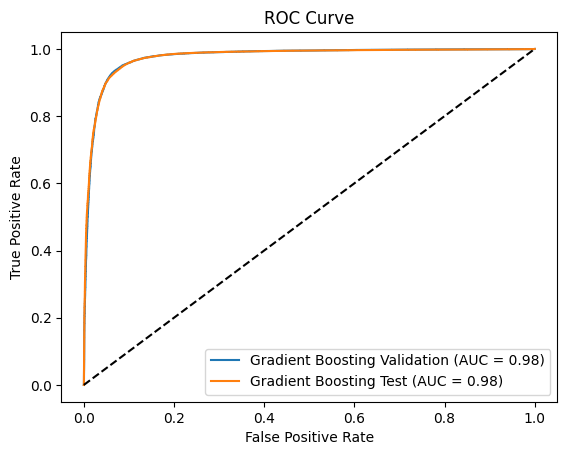

In [ ]:
df_main = pd.read_csv('df_clean_male.csv')

df_main= df_main.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

df_withdraws=df_main.copy()

del df_withdraws['result_aprueba']

df_pass=df_main.copy()

df_pass=df_pass[df_pass['result_stays']==1]

del df_pass['result_stays']

df_pass.result_aprueba.value_counts()

df_withdraws.result_stays.value_counts()

# Separar las variables de entrada y la variable de salida
X_large = df_withdraws.loc[:, df_withdraws.columns != 'result_stays']
y_large = df_withdraws.result_stays

# Split the data into training and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_large, y_large, test_size=0.2, random_state=42)
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

gb_clf = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.1, 1],
    'gb__max_depth': [3, 5, 7],
    'gb__n_estimators': [50, 100, 200],
    'gb__max_features': ['sqrt', 'log2']
}
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', gb_clf)
])
gb_grid_search = GridSearchCV(gb_pipeline, param_grid_gb, cv=3, n_jobs=-1, scoring=scoring, refit='roc_auc')
gb_grid_search.fit(X_train, y_train)

# Print the best parameters and score found during the search for each classifier
print("Gradient Boosting - Best parameters:", gb_grid_search.best_params_)
print("Gradient Boosting - Best score:", gb_grid_search.best_score_)
gb_best_model = gb_grid_search.best_estimator_
gb_val_score = gb_best_model.score(X_val, y_val)
print("Gradient Boosting - Validation score:", gb_val_score)

# Get other evaluation metrics for the best model
gb_val_preds = gb_best_model.predict(X_val)
gb_test_preds = gb_best_model.predict(X_test)
gb_val_accuracy = accuracy_score(y_val, gb_val_preds)
gb_test_accuracy = accuracy_score(y_test, gb_test_preds)
gb_val_auc = roc_auc_score(y_val, gb_val_preds)
gb_test_auc = roc_auc_score(y_test, gb_test_preds)
gb_val_f1 = f1_score(y_val, gb_val_preds)
gb_test_f1 = f1_score(y_test, gb_test_preds)
gb_val_recall = recall_score(y_val, gb_val_preds)
gb_test_recall = recall_score(y_test, gb_test_preds)
gb_val_precision = precision_score(y_val, gb_val_preds)
gb_test_precision = precision_score(y_test, gb_test_preds)
print("Gradient Boosting - Validation Accuracy:", gb_val_accuracy)
print("Gradient Boosting - Test Accuracy:", gb_test_accuracy)
print("Gradient Boosting - Validation AUC:", gb_val_auc)
print("Gradient Boosting - Test AUC:", gb_test_auc)
print("Gradient Boosting - Validation F1:", gb_val_f1)
print("Gradient Boosting - Test F1:", gb_test_f1)
print("Gradient Boosting - Validation Recall:", gb_val_recall)
print("Gradient Boosting - Test Recall:", gb_test_recall)
print("Gradient Boosting - Validation Precision:", gb_val_precision)
print("Gradient Boosting - Test Precision:", gb_test_precision)

# Compute ROC curve and AUC
gb_val_probs = gb_best_model.predict_proba(X_val)[:, 1]
gb_test_probs = gb_best_model.predict_proba(X_test)[:, 1]
gb_val_fpr, gb_val_tpr, _ = roc_curve(y_val, gb_val_probs)
gb_test_fpr, gb_test_tpr, _ = roc_curve(y_test, gb_test_probs)
gb_val_auc = auc(gb_val_fpr, gb_val_tpr)
gb_test_auc = auc(gb_test_fpr, gb_test_tpr)
# Plot ROC curve
plt.plot(gb_val_fpr, gb_val_tpr, label="Gradient Boosting Validation (AUC = {:.2f})".format(gb_val_auc))
plt.plot(gb_test_fpr, gb_test_tpr, label="Gradient Boosting Test (AUC = {:.2f})".format(gb_test_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


FEMALE

Gradient Boosting - Best parameters: {'gb__learning_rate': 1, 'gb__max_depth': 7, 'gb__max_features': 'sqrt', 'gb__n_estimators': 200}
Gradient Boosting - Best score: 0.9094535230205129
Gradient Boosting - Validation score: 0.940832311031424
Gradient Boosting - Validation Accuracy: 0.940832311031424
Gradient Boosting - Test Accuracy: 0.9402849863168822
Gradient Boosting - Validation AUC: 0.9368633145440612
Gradient Boosting - Test AUC: 0.9361342557758083
Gradient Boosting - Validation F1: 0.9510576848021232
Gradient Boosting - Test F1: 0.9506857855361596
Gradient Boosting - Validation Recall: 0.9565080860417648
Gradient Boosting - Test Recall: 0.9565299209634927
Gradient Boosting - Validation Precision: 0.945669046879851
Gradient Boosting - Test Precision: 0.9449126285785103


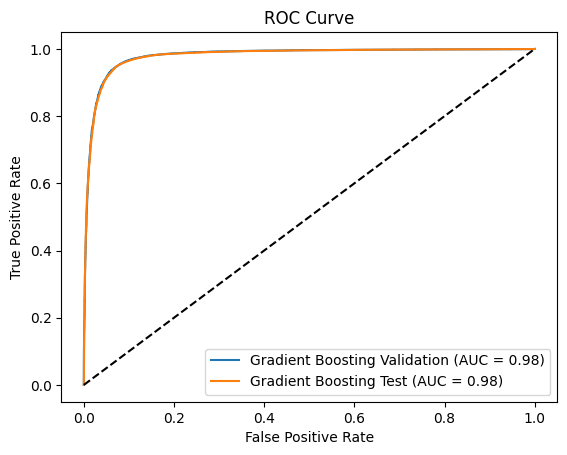

In [ ]:
df_main = pd.read_csv('df_clean_female.csv')

df_main= df_main.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

df_withdraws=df_main.copy()

del df_withdraws['result_aprueba']

df_pass=df_main.copy()

df_pass=df_pass[df_pass['result_stays']==1]

del df_pass['result_stays']

df_pass.result_aprueba.value_counts()

df_withdraws.result_stays.value_counts()

# Separar las variables de entrada y la variable de salida
X_large = df_withdraws.loc[:, df_withdraws.columns != 'result_stays']
y_large = df_withdraws.result_stays

# Split the data into training and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_large, y_large, test_size=0.2, random_state=42)
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

gb_clf = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.1, 1],
    'gb__max_depth': [3, 5, 7],
    'gb__n_estimators': [50, 100, 200],
    'gb__max_features': ['sqrt', 'log2']
}
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', gb_clf)
])
gb_grid_search = GridSearchCV(gb_pipeline, param_grid_gb, cv=2, n_jobs=-1, scoring=scoring, refit='roc_auc')
gb_grid_search.fit(X_train, y_train)

# Print the best parameters and score found during the search for each classifier
print("Gradient Boosting - Best parameters:", gb_grid_search.best_params_)
print("Gradient Boosting - Best score:", gb_grid_search.best_score_)
gb_best_model = gb_grid_search.best_estimator_
gb_val_score = gb_best_model.score(X_val, y_val)
print("Gradient Boosting - Validation score:", gb_val_score)

# Get other evaluation metrics for the best model
gb_val_preds = gb_best_model.predict(X_val)
gb_test_preds = gb_best_model.predict(X_test)
gb_val_accuracy = accuracy_score(y_val, gb_val_preds)
gb_test_accuracy = accuracy_score(y_test, gb_test_preds)
gb_val_auc = roc_auc_score(y_val, gb_val_preds)
gb_test_auc = roc_auc_score(y_test, gb_test_preds)
gb_val_f1 = f1_score(y_val, gb_val_preds)
gb_test_f1 = f1_score(y_test, gb_test_preds)
gb_val_recall = recall_score(y_val, gb_val_preds)
gb_test_recall = recall_score(y_test, gb_test_preds)
gb_val_precision = precision_score(y_val, gb_val_preds)
gb_test_precision = precision_score(y_test, gb_test_preds)
print("Gradient Boosting - Validation Accuracy:", gb_val_accuracy)
print("Gradient Boosting - Test Accuracy:", gb_test_accuracy)
print("Gradient Boosting - Validation AUC:", gb_val_auc)
print("Gradient Boosting - Test AUC:", gb_test_auc)
print("Gradient Boosting - Validation F1:", gb_val_f1)
print("Gradient Boosting - Test F1:", gb_test_f1)
print("Gradient Boosting - Validation Recall:", gb_val_recall)
print("Gradient Boosting - Test Recall:", gb_test_recall)
print("Gradient Boosting - Validation Precision:", gb_val_precision)
print("Gradient Boosting - Test Precision:", gb_test_precision)

# Compute ROC curve and AUC
gb_val_probs = gb_best_model.predict_proba(X_val)[:, 1]
gb_test_probs = gb_best_model.predict_proba(X_test)[:, 1]
gb_val_fpr, gb_val_tpr, _ = roc_curve(y_val, gb_val_probs)
gb_test_fpr, gb_test_tpr, _ = roc_curve(y_test, gb_test_probs)
gb_val_auc = auc(gb_val_fpr, gb_val_tpr)
gb_test_auc = auc(gb_test_fpr, gb_test_tpr)
# Plot ROC curve
plt.plot(gb_val_fpr, gb_val_tpr, label="Gradient Boosting Validation (AUC = {:.2f})".format(gb_val_auc))
plt.plot(gb_test_fpr, gb_test_tpr, label="Gradient Boosting Test (AUC = {:.2f})".format(gb_test_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


SOCIAL SCIENCES

Gradient Boosting - Best parameters: {'gb__learning_rate': 1, 'gb__max_depth': 7, 'gb__max_features': 'sqrt', 'gb__n_estimators': 200}
Gradient Boosting - Best score: 0.9126689370056205
Gradient Boosting - Validation score: 0.9528699968973007
Gradient Boosting - Validation Accuracy: 0.9528699968973007
Gradient Boosting - Test Accuracy: 0.9556443606036537
Gradient Boosting - Validation AUC: 0.945426550085117
Gradient Boosting - Test AUC: 0.9484384284703471
Gradient Boosting - Validation F1: 0.9637841832963784
Gradient Boosting - Test F1: 0.9660504967988297
Gradient Boosting - Validation Recall: 0.9709372147763847
Gradient Boosting - Test Recall: 0.9726472838561592
Gradient Boosting - Validation Precision: 0.9567357758212629
Gradient Boosting - Test Precision: 0.9595425897271389


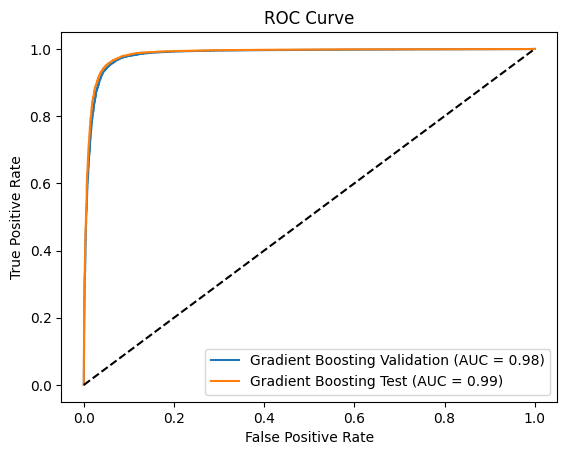

In [ ]:
df_main = pd.read_csv('df_clean_ss.csv')

df_main= df_main.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

df_withdraws=df_main.copy()

del df_withdraws['result_aprueba']

df_pass=df_main.copy()

df_pass=df_pass[df_pass['result_stays']==1]

del df_pass['result_stays']

df_pass.result_aprueba.value_counts()

df_withdraws.result_stays.value_counts()

# Separar las variables de entrada y la variable de salida
X_large = df_withdraws.loc[:, df_withdraws.columns != 'result_stays']
y_large = df_withdraws.result_stays

# Split the data into training and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_large, y_large, test_size=0.2, random_state=42)
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

gb_clf = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.1, 1],
    'gb__max_depth': [3, 5, 7],
    'gb__n_estimators': [50, 100, 200],
    'gb__max_features': ['sqrt', 'log2']
}
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', gb_clf)
])
gb_grid_search = GridSearchCV(gb_pipeline, param_grid_gb, cv=2, n_jobs=-1, scoring=scoring, refit='roc_auc')
gb_grid_search.fit(X_train, y_train)

# Print the best parameters and score found during the search for each classifier
print("Gradient Boosting - Best parameters:", gb_grid_search.best_params_)
print("Gradient Boosting - Best score:", gb_grid_search.best_score_)
gb_best_model = gb_grid_search.best_estimator_
gb_val_score = gb_best_model.score(X_val, y_val)
print("Gradient Boosting - Validation score:", gb_val_score)

# Get other evaluation metrics for the best model
gb_val_preds = gb_best_model.predict(X_val)
gb_test_preds = gb_best_model.predict(X_test)
gb_val_accuracy = accuracy_score(y_val, gb_val_preds)
gb_test_accuracy = accuracy_score(y_test, gb_test_preds)
gb_val_auc = roc_auc_score(y_val, gb_val_preds)
gb_test_auc = roc_auc_score(y_test, gb_test_preds)
gb_val_f1 = f1_score(y_val, gb_val_preds)
gb_test_f1 = f1_score(y_test, gb_test_preds)
gb_val_recall = recall_score(y_val, gb_val_preds)
gb_test_recall = recall_score(y_test, gb_test_preds)
gb_val_precision = precision_score(y_val, gb_val_preds)
gb_test_precision = precision_score(y_test, gb_test_preds)
print("Gradient Boosting - Validation Accuracy:", gb_val_accuracy)
print("Gradient Boosting - Test Accuracy:", gb_test_accuracy)
print("Gradient Boosting - Validation AUC:", gb_val_auc)
print("Gradient Boosting - Test AUC:", gb_test_auc)
print("Gradient Boosting - Validation F1:", gb_val_f1)
print("Gradient Boosting - Test F1:", gb_test_f1)
print("Gradient Boosting - Validation Recall:", gb_val_recall)
print("Gradient Boosting - Test Recall:", gb_test_recall)
print("Gradient Boosting - Validation Precision:", gb_val_precision)
print("Gradient Boosting - Test Precision:", gb_test_precision)

# Compute ROC curve and AUC
gb_val_probs = gb_best_model.predict_proba(X_val)[:, 1]
gb_test_probs = gb_best_model.predict_proba(X_test)[:, 1]
gb_val_fpr, gb_val_tpr, _ = roc_curve(y_val, gb_val_probs)
gb_test_fpr, gb_test_tpr, _ = roc_curve(y_test, gb_test_probs)
gb_val_auc = auc(gb_val_fpr, gb_val_tpr)
gb_test_auc = auc(gb_test_fpr, gb_test_tpr)
# Plot ROC curve
plt.plot(gb_val_fpr, gb_val_tpr, label="Gradient Boosting Validation (AUC = {:.2f})".format(gb_val_auc))
plt.plot(gb_test_fpr, gb_test_tpr, label="Gradient Boosting Test (AUC = {:.2f})".format(gb_test_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


STEM

Gradient Boosting - Best parameters: {'gb__learning_rate': 1, 'gb__max_depth': 7, 'gb__max_features': 'log2', 'gb__n_estimators': 200}
Gradient Boosting - Best score: 0.904995102574037
Gradient Boosting - Validation score: 0.9256302930010708
Gradient Boosting - Validation Accuracy: 0.9256302930010708
Gradient Boosting - Test Accuracy: 0.9254620496313986
Gradient Boosting - Validation AUC: 0.9232142238131993
Gradient Boosting - Test AUC: 0.9227876107416987
Gradient Boosting - Validation F1: 0.9345161566812376
Gradient Boosting - Test F1: 0.9350611169533114
Gradient Boosting - Validation Recall: 0.9423509075194468
Gradient Boosting - Test Recall: 0.9419738460837472
Gradient Boosting - Validation Precision: 0.9268106086365182
Gradient Boosting - Test Precision: 0.9282491076038883


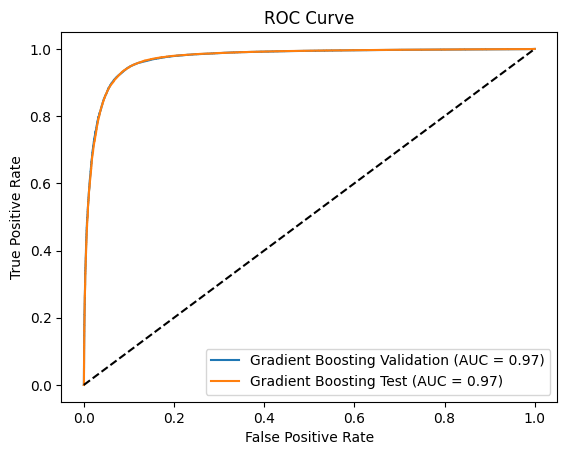

In [ ]:
df_main = pd.read_csv('df_clean_stem.csv')

df_main= df_main.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

df_withdraws=df_main.copy()

del df_withdraws['result_aprueba']

df_pass=df_main.copy()

df_pass=df_pass[df_pass['result_stays']==1]

del df_pass['result_stays']

df_pass.result_aprueba.value_counts()

df_withdraws.result_stays.value_counts()

# Separar las variables de entrada y la variable de salida
X_large = df_withdraws.loc[:, df_withdraws.columns != 'result_stays']
y_large = df_withdraws.result_stays

# Split the data into training and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_large, y_large, test_size=0.2, random_state=42)
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

gb_clf = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.1, 1],
    'gb__max_depth': [3, 5, 7],
    'gb__n_estimators': [50, 100, 200],
    'gb__max_features': ['sqrt', 'log2']
}
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', gb_clf)
])
gb_grid_search = GridSearchCV(gb_pipeline, param_grid_gb, cv=2, n_jobs=-1, scoring=scoring, refit='roc_auc')
gb_grid_search.fit(X_train, y_train)

# Print the best parameters and score found during the search for each classifier
print("Gradient Boosting - Best parameters:", gb_grid_search.best_params_)
print("Gradient Boosting - Best score:", gb_grid_search.best_score_)
gb_best_model = gb_grid_search.best_estimator_
gb_val_score = gb_best_model.score(X_val, y_val)
print("Gradient Boosting - Validation score:", gb_val_score)

# Get other evaluation metrics for the best model
gb_val_preds = gb_best_model.predict(X_val)
gb_test_preds = gb_best_model.predict(X_test)
gb_val_accuracy = accuracy_score(y_val, gb_val_preds)
gb_test_accuracy = accuracy_score(y_test, gb_test_preds)
gb_val_auc = roc_auc_score(y_val, gb_val_preds)
gb_test_auc = roc_auc_score(y_test, gb_test_preds)
gb_val_f1 = f1_score(y_val, gb_val_preds)
gb_test_f1 = f1_score(y_test, gb_test_preds)
gb_val_recall = recall_score(y_val, gb_val_preds)
gb_test_recall = recall_score(y_test, gb_test_preds)
gb_val_precision = precision_score(y_val, gb_val_preds)
gb_test_precision = precision_score(y_test, gb_test_preds)
print("Gradient Boosting - Validation Accuracy:", gb_val_accuracy)
print("Gradient Boosting - Test Accuracy:", gb_test_accuracy)
print("Gradient Boosting - Validation AUC:", gb_val_auc)
print("Gradient Boosting - Test AUC:", gb_test_auc)
print("Gradient Boosting - Validation F1:", gb_val_f1)
print("Gradient Boosting - Test F1:", gb_test_f1)
print("Gradient Boosting - Validation Recall:", gb_val_recall)
print("Gradient Boosting - Test Recall:", gb_test_recall)
print("Gradient Boosting - Validation Precision:", gb_val_precision)
print("Gradient Boosting - Test Precision:", gb_test_precision)

# Compute ROC curve and AUC
gb_val_probs = gb_best_model.predict_proba(X_val)[:, 1]
gb_test_probs = gb_best_model.predict_proba(X_test)[:, 1]
gb_val_fpr, gb_val_tpr, _ = roc_curve(y_val, gb_val_probs)
gb_test_fpr, gb_test_tpr, _ = roc_curve(y_test, gb_test_probs)
gb_val_auc = auc(gb_val_fpr, gb_val_tpr)
gb_test_auc = auc(gb_test_fpr, gb_test_tpr)
# Plot ROC curve
plt.plot(gb_val_fpr, gb_val_tpr, label="Gradient Boosting Validation (AUC = {:.2f})".format(gb_val_auc))
plt.plot(gb_test_fpr, gb_test_tpr, label="Gradient Boosting Test (AUC = {:.2f})".format(gb_test_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


DISABLED

Gradient Boosting - Best parameters: {'gb__learning_rate': 1, 'gb__max_depth': 7, 'gb__max_features': 'sqrt', 'gb__n_estimators': 200}
Gradient Boosting - Best score: 0.9543888009425815
Gradient Boosting - Validation score: 0.976407330187644
Gradient Boosting - Validation Accuracy: 0.976407330187644
Gradient Boosting - Test Accuracy: 0.9770871740848038
Gradient Boosting - Validation AUC: 0.975943908611206
Gradient Boosting - Test AUC: 0.9769281644281644
Gradient Boosting - Validation F1: 0.9780858220364896
Gradient Boosting - Test F1: 0.9784457841275084
Gradient Boosting - Validation Recall: 0.9823914823914824
Gradient Boosting - Test Recall: 0.9794973544973545
Gradient Boosting - Validation Precision: 0.973817738989243
Gradient Boosting - Test Precision: 0.9773964692295001


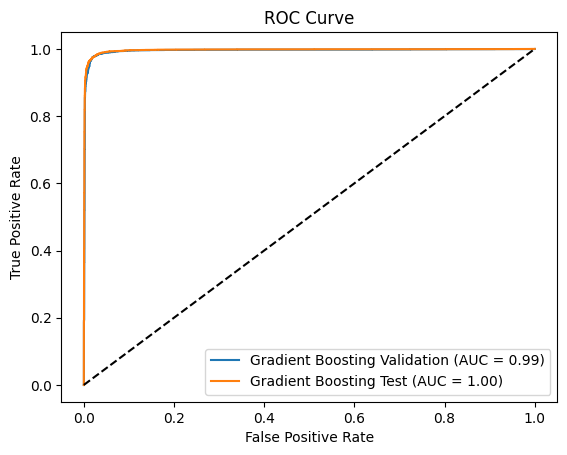

In [ ]:
df_main = pd.read_csv('df_clean_disabled.csv')

df_main= df_main.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

df_withdraws=df_main.copy()

del df_withdraws['result_aprueba']

df_pass=df_main.copy()

df_pass=df_pass[df_pass['result_stays']==1]

del df_pass['result_stays']

df_pass.result_aprueba.value_counts()

df_withdraws.result_stays.value_counts()

# Separar las variables de entrada y la variable de salida
X_large = df_withdraws.loc[:, df_withdraws.columns != 'result_stays']
y_large = df_withdraws.result_stays

# Split the data into training and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_large, y_large, test_size=0.2, random_state=42)
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

gb_clf = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.1, 1],
    'gb__max_depth': [3, 5, 7],
    'gb__n_estimators': [50, 100, 200],
    'gb__max_features': ['sqrt', 'log2']
}
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', gb_clf)
])
gb_grid_search = GridSearchCV(gb_pipeline, param_grid_gb, cv=2, n_jobs=-1, scoring=scoring, refit='roc_auc')
gb_grid_search.fit(X_train, y_train)

# Print the best parameters and score found during the search for each classifier
print("Gradient Boosting - Best parameters:", gb_grid_search.best_params_)
print("Gradient Boosting - Best score:", gb_grid_search.best_score_)
gb_best_model = gb_grid_search.best_estimator_
gb_val_score = gb_best_model.score(X_val, y_val)
print("Gradient Boosting - Validation score:", gb_val_score)

# Get other evaluation metrics for the best model
gb_val_preds = gb_best_model.predict(X_val)
gb_test_preds = gb_best_model.predict(X_test)
gb_val_accuracy = accuracy_score(y_val, gb_val_preds)
gb_test_accuracy = accuracy_score(y_test, gb_test_preds)
gb_val_auc = roc_auc_score(y_val, gb_val_preds)
gb_test_auc = roc_auc_score(y_test, gb_test_preds)
gb_val_f1 = f1_score(y_val, gb_val_preds)
gb_test_f1 = f1_score(y_test, gb_test_preds)
gb_val_recall = recall_score(y_val, gb_val_preds)
gb_test_recall = recall_score(y_test, gb_test_preds)
gb_val_precision = precision_score(y_val, gb_val_preds)
gb_test_precision = precision_score(y_test, gb_test_preds)
print("Gradient Boosting - Validation Accuracy:", gb_val_accuracy)
print("Gradient Boosting - Test Accuracy:", gb_test_accuracy)
print("Gradient Boosting - Validation AUC:", gb_val_auc)
print("Gradient Boosting - Test AUC:", gb_test_auc)
print("Gradient Boosting - Validation F1:", gb_val_f1)
print("Gradient Boosting - Test F1:", gb_test_f1)
print("Gradient Boosting - Validation Recall:", gb_val_recall)
print("Gradient Boosting - Test Recall:", gb_test_recall)
print("Gradient Boosting - Validation Precision:", gb_val_precision)
print("Gradient Boosting - Test Precision:", gb_test_precision)

# Compute ROC curve and AUC
gb_val_probs = gb_best_model.predict_proba(X_val)[:, 1]
gb_test_probs = gb_best_model.predict_proba(X_test)[:, 1]
gb_val_fpr, gb_val_tpr, _ = roc_curve(y_val, gb_val_probs)
gb_test_fpr, gb_test_tpr, _ = roc_curve(y_test, gb_test_probs)
gb_val_auc = auc(gb_val_fpr, gb_val_tpr)
gb_test_auc = auc(gb_test_fpr, gb_test_tpr)
# Plot ROC curve
plt.plot(gb_val_fpr, gb_val_tpr, label="Gradient Boosting Validation (AUC = {:.2f})".format(gb_val_auc))
plt.plot(gb_test_fpr, gb_test_tpr, label="Gradient Boosting Test (AUC = {:.2f})".format(gb_test_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


NOT DISABLED

Gradient Boosting - Best parameters: {'gb__learning_rate': 1, 'gb__max_depth': 7, 'gb__max_features': 'sqrt', 'gb__n_estimators': 200}
Gradient Boosting - Best score: 0.8846783760249557
Gradient Boosting - Validation score: 0.9140945773750531
Gradient Boosting - Validation Accuracy: 0.9140945773750531
Gradient Boosting - Test Accuracy: 0.9149369956109302
Gradient Boosting - Validation AUC: 0.9079868077464591
Gradient Boosting - Test AUC: 0.9085651737275613
Gradient Boosting - Validation F1: 0.929270164463139
Gradient Boosting - Test F1: 0.9302897631460882
Gradient Boosting - Validation Recall: 0.9380454607856596
Gradient Boosting - Test Recall: 0.9390792391541993
Gradient Boosting - Validation Precision: 0.9206575300277179
Gradient Boosting - Test Precision: 0.921663294709092


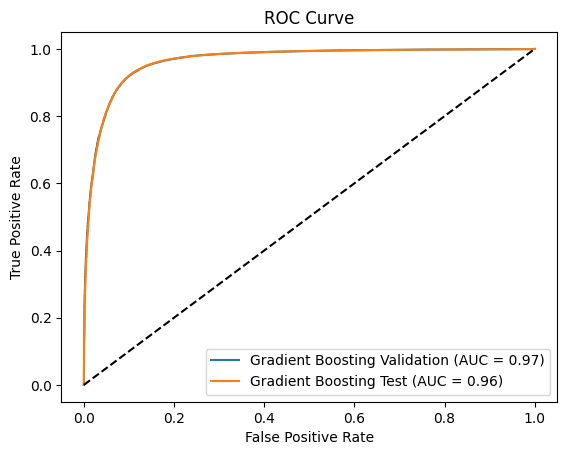

In [ ]:
df_main = pd.read_csv('df_clean_not_disabled.csv')

df_main= df_main.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

df_withdraws=df_main.copy()

del df_withdraws['result_aprueba']

df_pass=df_main.copy()

df_pass=df_pass[df_pass['result_stays']==1]

del df_pass['result_stays']

df_pass.result_aprueba.value_counts()

df_withdraws.result_stays.value_counts()

# Separar las variables de entrada y la variable de salida
X_large = df_withdraws.loc[:, df_withdraws.columns != 'result_stays']
y_large = df_withdraws.result_stays

# Split the data into training and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_large, y_large, test_size=0.2, random_state=42)
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

gb_clf = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.1, 1],
    'gb__max_depth': [3, 5, 7],
    'gb__n_estimators': [50, 100, 200],
    'gb__max_features': ['sqrt', 'log2']
}
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', gb_clf)
])
gb_grid_search = GridSearchCV(gb_pipeline, param_grid_gb, cv=2, n_jobs=-1, scoring=scoring, refit='roc_auc')
gb_grid_search.fit(X_train, y_train)

# Print the best parameters and score found during the search for each classifier
print("Gradient Boosting - Best parameters:", gb_grid_search.best_params_)
print("Gradient Boosting - Best score:", gb_grid_search.best_score_)
gb_best_model = gb_grid_search.best_estimator_
gb_val_score = gb_best_model.score(X_val, y_val)
print("Gradient Boosting - Validation score:", gb_val_score)

# Get other evaluation metrics for the best model
gb_val_preds = gb_best_model.predict(X_val)
gb_test_preds = gb_best_model.predict(X_test)
gb_val_accuracy = accuracy_score(y_val, gb_val_preds)
gb_test_accuracy = accuracy_score(y_test, gb_test_preds)
gb_val_auc = roc_auc_score(y_val, gb_val_preds)
gb_test_auc = roc_auc_score(y_test, gb_test_preds)
gb_val_f1 = f1_score(y_val, gb_val_preds)
gb_test_f1 = f1_score(y_test, gb_test_preds)
gb_val_recall = recall_score(y_val, gb_val_preds)
gb_test_recall = recall_score(y_test, gb_test_preds)
gb_val_precision = precision_score(y_val, gb_val_preds)
gb_test_precision = precision_score(y_test, gb_test_preds)
print("Gradient Boosting - Validation Accuracy:", gb_val_accuracy)
print("Gradient Boosting - Test Accuracy:", gb_test_accuracy)
print("Gradient Boosting - Validation AUC:", gb_val_auc)
print("Gradient Boosting - Test AUC:", gb_test_auc)
print("Gradient Boosting - Validation F1:", gb_val_f1)
print("Gradient Boosting - Test F1:", gb_test_f1)
print("Gradient Boosting - Validation Recall:", gb_val_recall)
print("Gradient Boosting - Test Recall:", gb_test_recall)
print("Gradient Boosting - Validation Precision:", gb_val_precision)
print("Gradient Boosting - Test Precision:", gb_test_precision)

# Compute ROC curve and AUC
gb_val_probs = gb_best_model.predict_proba(X_val)[:, 1]
gb_test_probs = gb_best_model.predict_proba(X_test)[:, 1]
gb_val_fpr, gb_val_tpr, _ = roc_curve(y_val, gb_val_probs)
gb_test_fpr, gb_test_tpr, _ = roc_curve(y_test, gb_test_probs)
gb_val_auc = auc(gb_val_fpr, gb_val_tpr)
gb_test_auc = auc(gb_test_fpr, gb_test_tpr)
# Plot ROC curve
plt.plot(gb_val_fpr, gb_val_tpr, label="Gradient Boosting Validation (AUC = {:.2f})".format(gb_val_auc))
plt.plot(gb_test_fpr, gb_test_tpr, label="Gradient Boosting Test (AUC = {:.2f})".format(gb_test_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


AGE YOUNG

Gradient Boosting - Best parameters: {'gb__learning_rate': 1, 'gb__max_depth': 7, 'gb__max_features': 'sqrt', 'gb__n_estimators': 200}
Gradient Boosting - Best score: 0.9029119685324523
Gradient Boosting - Validation score: 0.9229255890676311
Gradient Boosting - Validation Accuracy: 0.9229255890676311
Gradient Boosting - Test Accuracy: 0.9222993014443274
Gradient Boosting - Validation AUC: 0.9178867213120694
Gradient Boosting - Test AUC: 0.9169550269967719
Gradient Boosting - Validation F1: 0.9359540247230292
Gradient Boosting - Test F1: 0.9357287348034209
Gradient Boosting - Validation Recall: 0.9439667199350633
Gradient Boosting - Test Recall: 0.943876520263445
Gradient Boosting - Validation Precision: 0.9280762132774703
Gradient Boosting - Test Precision: 0.9277204130262113


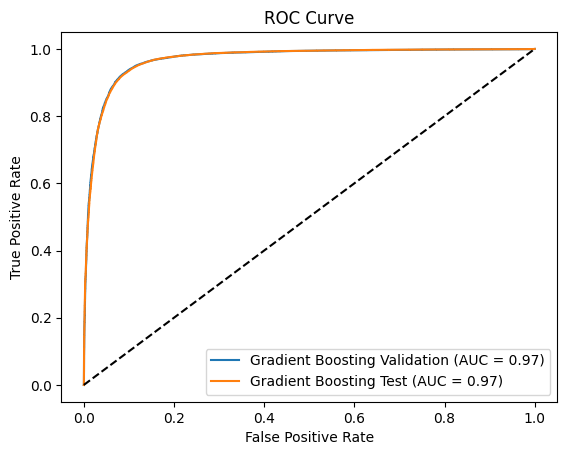

In [ ]:
df_main = pd.read_csv('df_clean_young.csv')

df_main= df_main.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

df_withdraws=df_main.copy()

del df_withdraws['result_aprueba']

df_pass=df_main.copy()

df_pass=df_pass[df_pass['result_stays']==1]

del df_pass['result_stays']

df_pass.result_aprueba.value_counts()

df_withdraws.result_stays.value_counts()

# Separar las variables de entrada y la variable de salida
X_large = df_withdraws.loc[:, df_withdraws.columns != 'result_stays']
y_large = df_withdraws.result_stays

# Split the data into training and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_large, y_large, test_size=0.2, random_state=42)
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

gb_clf = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.1, 1],
    'gb__max_depth': [3, 5, 7],
    'gb__n_estimators': [50, 100, 200],
    'gb__max_features': ['sqrt', 'log2']
}
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', gb_clf)
])
gb_grid_search = GridSearchCV(gb_pipeline, param_grid_gb, cv=2, n_jobs=-1, scoring=scoring, refit='roc_auc')
gb_grid_search.fit(X_train, y_train)

# Print the best parameters and score found during the search for each classifier
print("Gradient Boosting - Best parameters:", gb_grid_search.best_params_)
print("Gradient Boosting - Best score:", gb_grid_search.best_score_)
gb_best_model = gb_grid_search.best_estimator_
gb_val_score = gb_best_model.score(X_val, y_val)
print("Gradient Boosting - Validation score:", gb_val_score)

# Get other evaluation metrics for the best model
gb_val_preds = gb_best_model.predict(X_val)
gb_test_preds = gb_best_model.predict(X_test)
gb_val_accuracy = accuracy_score(y_val, gb_val_preds)
gb_test_accuracy = accuracy_score(y_test, gb_test_preds)
gb_val_auc = roc_auc_score(y_val, gb_val_preds)
gb_test_auc = roc_auc_score(y_test, gb_test_preds)
gb_val_f1 = f1_score(y_val, gb_val_preds)
gb_test_f1 = f1_score(y_test, gb_test_preds)
gb_val_recall = recall_score(y_val, gb_val_preds)
gb_test_recall = recall_score(y_test, gb_test_preds)
gb_val_precision = precision_score(y_val, gb_val_preds)
gb_test_precision = precision_score(y_test, gb_test_preds)
print("Gradient Boosting - Validation Accuracy:", gb_val_accuracy)
print("Gradient Boosting - Test Accuracy:", gb_test_accuracy)
print("Gradient Boosting - Validation AUC:", gb_val_auc)
print("Gradient Boosting - Test AUC:", gb_test_auc)
print("Gradient Boosting - Validation F1:", gb_val_f1)
print("Gradient Boosting - Test F1:", gb_test_f1)
print("Gradient Boosting - Validation Recall:", gb_val_recall)
print("Gradient Boosting - Test Recall:", gb_test_recall)
print("Gradient Boosting - Validation Precision:", gb_val_precision)
print("Gradient Boosting - Test Precision:", gb_test_precision)

# Compute ROC curve and AUC
gb_val_probs = gb_best_model.predict_proba(X_val)[:, 1]
gb_test_probs = gb_best_model.predict_proba(X_test)[:, 1]
gb_val_fpr, gb_val_tpr, _ = roc_curve(y_val, gb_val_probs)
gb_test_fpr, gb_test_tpr, _ = roc_curve(y_test, gb_test_probs)
gb_val_auc = auc(gb_val_fpr, gb_val_tpr)
gb_test_auc = auc(gb_test_fpr, gb_test_tpr)
# Plot ROC curve
plt.plot(gb_val_fpr, gb_val_tpr, label="Gradient Boosting Validation (AUC = {:.2f})".format(gb_val_auc))
plt.plot(gb_test_fpr, gb_test_tpr, label="Gradient Boosting Test (AUC = {:.2f})".format(gb_test_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


AGE OLD

Gradient Boosting - Best parameters: {'gb__learning_rate': 1, 'gb__max_depth': 7, 'gb__max_features': 'sqrt', 'gb__n_estimators': 200}
Gradient Boosting - Best score: 0.9208368843620074
Gradient Boosting - Validation score: 0.9538666378782972
Gradient Boosting - Validation Accuracy: 0.9538666378782972
Gradient Boosting - Test Accuracy: 0.95385324006103
Gradient Boosting - Validation AUC: 0.951204039094181
Gradient Boosting - Test AUC: 0.9506318229740249
Gradient Boosting - Validation F1: 0.9609860012172855
Gradient Boosting - Test F1: 0.9612979550447861
Gradient Boosting - Validation Recall: 0.9663382091927291
Gradient Boosting - Test Recall: 0.9681466712055634
Gradient Boosting - Validation Precision: 0.9556927546758671
Gradient Boosting - Test Precision: 0.9545454545454546


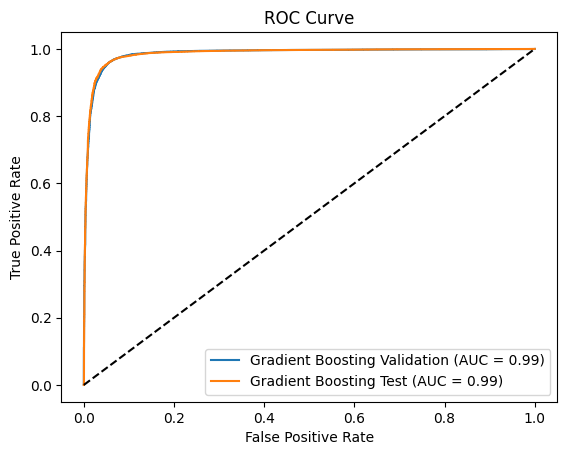

In [ ]:
df_main = pd.read_csv('df_clean_old.csv')

df_main= df_main.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

df_withdraws=df_main.copy()

del df_withdraws['result_aprueba']

df_pass=df_main.copy()

df_pass=df_pass[df_pass['result_stays']==1]

del df_pass['result_stays']

df_pass.result_aprueba.value_counts()

df_withdraws.result_stays.value_counts()

# Separar las variables de entrada y la variable de salida
X_large = df_withdraws.loc[:, df_withdraws.columns != 'result_stays']
y_large = df_withdraws.result_stays

# Split the data into training and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_large, y_large, test_size=0.2, random_state=42)
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

gb_clf = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.1, 1],
    'gb__max_depth': [3, 5, 7],
    'gb__n_estimators': [50, 100, 200],
    'gb__max_features': ['sqrt', 'log2']
}
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', gb_clf)
])
gb_grid_search = GridSearchCV(gb_pipeline, param_grid_gb, cv=2, n_jobs=-1, scoring=scoring, refit='roc_auc')
gb_grid_search.fit(X_train, y_train)

# Print the best parameters and score found during the search for each classifier
print("Gradient Boosting - Best parameters:", gb_grid_search.best_params_)
print("Gradient Boosting - Best score:", gb_grid_search.best_score_)
gb_best_model = gb_grid_search.best_estimator_
gb_val_score = gb_best_model.score(X_val, y_val)
print("Gradient Boosting - Validation score:", gb_val_score)

# Get other evaluation metrics for the best model
gb_val_preds = gb_best_model.predict(X_val)
gb_test_preds = gb_best_model.predict(X_test)
gb_val_accuracy = accuracy_score(y_val, gb_val_preds)
gb_test_accuracy = accuracy_score(y_test, gb_test_preds)
gb_val_auc = roc_auc_score(y_val, gb_val_preds)
gb_test_auc = roc_auc_score(y_test, gb_test_preds)
gb_val_f1 = f1_score(y_val, gb_val_preds)
gb_test_f1 = f1_score(y_test, gb_test_preds)
gb_val_recall = recall_score(y_val, gb_val_preds)
gb_test_recall = recall_score(y_test, gb_test_preds)
gb_val_precision = precision_score(y_val, gb_val_preds)
gb_test_precision = precision_score(y_test, gb_test_preds)
print("Gradient Boosting - Validation Accuracy:", gb_val_accuracy)
print("Gradient Boosting - Test Accuracy:", gb_test_accuracy)
print("Gradient Boosting - Validation AUC:", gb_val_auc)
print("Gradient Boosting - Test AUC:", gb_test_auc)
print("Gradient Boosting - Validation F1:", gb_val_f1)
print("Gradient Boosting - Test F1:", gb_test_f1)
print("Gradient Boosting - Validation Recall:", gb_val_recall)
print("Gradient Boosting - Test Recall:", gb_test_recall)
print("Gradient Boosting - Validation Precision:", gb_val_precision)
print("Gradient Boosting - Test Precision:", gb_test_precision)

# Compute ROC curve and AUC
gb_val_probs = gb_best_model.predict_proba(X_val)[:, 1]
gb_test_probs = gb_best_model.predict_proba(X_test)[:, 1]
gb_val_fpr, gb_val_tpr, _ = roc_curve(y_val, gb_val_probs)
gb_test_fpr, gb_test_tpr, _ = roc_curve(y_test, gb_test_probs)
gb_val_auc = auc(gb_val_fpr, gb_val_tpr)
gb_test_auc = auc(gb_test_fpr, gb_test_tpr)
# Plot ROC curve
plt.plot(gb_val_fpr, gb_val_tpr, label="Gradient Boosting Validation (AUC = {:.2f})".format(gb_val_auc))
plt.plot(gb_test_fpr, gb_test_tpr, label="Gradient Boosting Test (AUC = {:.2f})".format(gb_test_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


MIDDLE AGE

Gradient Boosting - Best parameters: {'gb__learning_rate': 1, 'gb__max_depth': 7, 'gb__max_features': 'sqrt', 'gb__n_estimators': 200}
Gradient Boosting - Best score: 0.9219607976182052
Gradient Boosting - Validation score: 0.9524054919571538
Gradient Boosting - Validation Accuracy: 0.9524054919571538
Gradient Boosting - Test Accuracy: 0.9522365205100268
Gradient Boosting - Validation AUC: 0.9490710006583312
Gradient Boosting - Test AUC: 0.9493244082525104
Gradient Boosting - Validation F1: 0.9601872094097362
Gradient Boosting - Test F1: 0.9599861851194
Gradient Boosting - Validation Recall: 0.9668857745256109
Gradient Boosting - Test Recall: 0.9648418129524943
Gradient Boosting - Validation Precision: 0.9535808207449086
Gradient Boosting - Test Precision: 0.9551791850760923


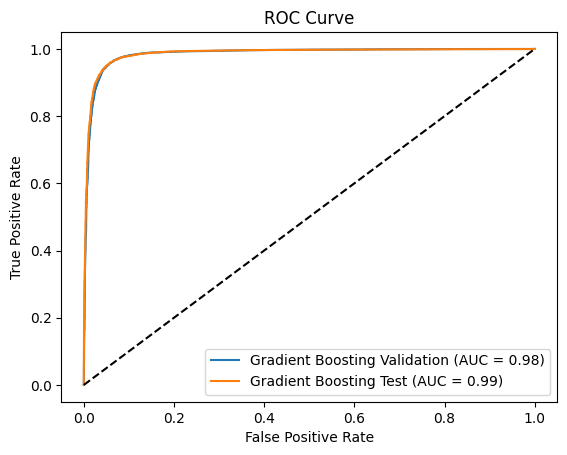

In [ ]:
df_main = pd.read_csv('df_clean_middle_age.csv')

df_main= df_main.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

df_withdraws=df_main.copy()

del df_withdraws['result_aprueba']

df_pass=df_main.copy()

df_pass=df_pass[df_pass['result_stays']==1]

del df_pass['result_stays']

df_pass.result_aprueba.value_counts()

df_withdraws.result_stays.value_counts()

# Separar las variables de entrada y la variable de salida
X_large = df_withdraws.loc[:, df_withdraws.columns != 'result_stays']
y_large = df_withdraws.result_stays

# Split the data into training and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_large, y_large, test_size=0.2, random_state=42)
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

gb_clf = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.1, 1],
    'gb__max_depth': [3, 5, 7],
    'gb__n_estimators': [50, 100, 200],
    'gb__max_features': ['sqrt', 'log2']
}
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', gb_clf)
])
gb_grid_search = GridSearchCV(gb_pipeline, param_grid_gb, cv=2, n_jobs=-1, scoring=scoring, refit='roc_auc')
gb_grid_search.fit(X_train, y_train)

# Print the best parameters and score found during the search for each classifier
print("Gradient Boosting - Best parameters:", gb_grid_search.best_params_)
print("Gradient Boosting - Best score:", gb_grid_search.best_score_)
gb_best_model = gb_grid_search.best_estimator_
gb_val_score = gb_best_model.score(X_val, y_val)
print("Gradient Boosting - Validation score:", gb_val_score)

# Get other evaluation metrics for the best model
gb_val_preds = gb_best_model.predict(X_val)
gb_test_preds = gb_best_model.predict(X_test)
gb_val_accuracy = accuracy_score(y_val, gb_val_preds)
gb_test_accuracy = accuracy_score(y_test, gb_test_preds)
gb_val_auc = roc_auc_score(y_val, gb_val_preds)
gb_test_auc = roc_auc_score(y_test, gb_test_preds)
gb_val_f1 = f1_score(y_val, gb_val_preds)
gb_test_f1 = f1_score(y_test, gb_test_preds)
gb_val_recall = recall_score(y_val, gb_val_preds)
gb_test_recall = recall_score(y_test, gb_test_preds)
gb_val_precision = precision_score(y_val, gb_val_preds)
gb_test_precision = precision_score(y_test, gb_test_preds)
print("Gradient Boosting - Validation Accuracy:", gb_val_accuracy)
print("Gradient Boosting - Test Accuracy:", gb_test_accuracy)
print("Gradient Boosting - Validation AUC:", gb_val_auc)
print("Gradient Boosting - Test AUC:", gb_test_auc)
print("Gradient Boosting - Validation F1:", gb_val_f1)
print("Gradient Boosting - Test F1:", gb_test_f1)
print("Gradient Boosting - Validation Recall:", gb_val_recall)
print("Gradient Boosting - Test Recall:", gb_test_recall)
print("Gradient Boosting - Validation Precision:", gb_val_precision)
print("Gradient Boosting - Test Precision:", gb_test_precision)

# Compute ROC curve and AUC
gb_val_probs = gb_best_model.predict_proba(X_val)[:, 1]
gb_test_probs = gb_best_model.predict_proba(X_test)[:, 1]
gb_val_fpr, gb_val_tpr, _ = roc_curve(y_val, gb_val_probs)
gb_test_fpr, gb_test_tpr, _ = roc_curve(y_test, gb_test_probs)
gb_val_auc = auc(gb_val_fpr, gb_val_tpr)
gb_test_auc = auc(gb_test_fpr, gb_test_tpr)
# Plot ROC curve
plt.plot(gb_val_fpr, gb_val_tpr, label="Gradient Boosting Validation (AUC = {:.2f})".format(gb_val_auc))
plt.plot(gb_test_fpr, gb_test_tpr, label="Gradient Boosting Test (AUC = {:.2f})".format(gb_test_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


LOW ED

Gradient Boosting - Best parameters: {'gb__learning_rate': 1, 'gb__max_depth': 7, 'gb__max_features': 'sqrt', 'gb__n_estimators': 200}
Gradient Boosting - Best score: 0.9307164186120918
Gradient Boosting - Validation score: 0.9539015297596092
Gradient Boosting - Validation Accuracy: 0.9539015297596092
Gradient Boosting - Test Accuracy: 0.9541527829199062
Gradient Boosting - Validation AUC: 0.9515183165555745
Gradient Boosting - Test AUC: 0.9513094761693721
Gradient Boosting - Validation F1: 0.961122314013747
Gradient Boosting - Test F1: 0.9614832990617062
Gradient Boosting - Validation Recall: 0.9646572361262241
Gradient Boosting - Test Recall: 0.9667790249157313
Gradient Boosting - Validation Precision: 0.9576132042862081
Gradient Boosting - Test Precision: 0.9562452739396439


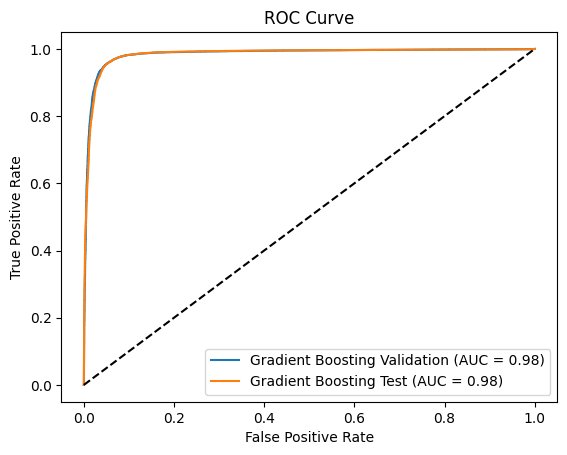

In [7]:
df_main = pd.read_csv('df_clean_low_ed.csv')

df_main= df_main.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

df_withdraws=df_main.copy()

del df_withdraws['result_aprueba']

df_pass=df_main.copy()

df_pass=df_pass[df_pass['result_stays']==1]

del df_pass['result_stays']

df_pass.result_aprueba.value_counts()

df_withdraws.result_stays.value_counts()

# Separar las variables de entrada y la variable de salida
X_large = df_withdraws.loc[:, df_withdraws.columns != 'result_stays']
y_large = df_withdraws.result_stays

# Split the data into training and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_large, y_large, test_size=0.2, random_state=42)
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

gb_clf = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.1, 1],
    'gb__max_depth': [3, 5, 7],
    'gb__n_estimators': [50, 100, 200],
    'gb__max_features': ['sqrt', 'log2']
}
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', gb_clf)
])
gb_grid_search = GridSearchCV(gb_pipeline, param_grid_gb, cv=2, n_jobs=-1, scoring=scoring, refit='roc_auc')
gb_grid_search.fit(X_train, y_train)

# Print the best parameters and score found during the search for each classifier
print("Gradient Boosting - Best parameters:", gb_grid_search.best_params_)
print("Gradient Boosting - Best score:", gb_grid_search.best_score_)
gb_best_model = gb_grid_search.best_estimator_
gb_val_score = gb_best_model.score(X_val, y_val)
print("Gradient Boosting - Validation score:", gb_val_score)

# Get other evaluation metrics for the best model
gb_val_preds = gb_best_model.predict(X_val)
gb_test_preds = gb_best_model.predict(X_test)
gb_val_accuracy = accuracy_score(y_val, gb_val_preds)
gb_test_accuracy = accuracy_score(y_test, gb_test_preds)
gb_val_auc = roc_auc_score(y_val, gb_val_preds)
gb_test_auc = roc_auc_score(y_test, gb_test_preds)
gb_val_f1 = f1_score(y_val, gb_val_preds)
gb_test_f1 = f1_score(y_test, gb_test_preds)
gb_val_recall = recall_score(y_val, gb_val_preds)
gb_test_recall = recall_score(y_test, gb_test_preds)
gb_val_precision = precision_score(y_val, gb_val_preds)
gb_test_precision = precision_score(y_test, gb_test_preds)
print("Gradient Boosting - Validation Accuracy:", gb_val_accuracy)
print("Gradient Boosting - Test Accuracy:", gb_test_accuracy)
print("Gradient Boosting - Validation AUC:", gb_val_auc)
print("Gradient Boosting - Test AUC:", gb_test_auc)
print("Gradient Boosting - Validation F1:", gb_val_f1)
print("Gradient Boosting - Test F1:", gb_test_f1)
print("Gradient Boosting - Validation Recall:", gb_val_recall)
print("Gradient Boosting - Test Recall:", gb_test_recall)
print("Gradient Boosting - Validation Precision:", gb_val_precision)
print("Gradient Boosting - Test Precision:", gb_test_precision)

# Compute ROC curve and AUC
gb_val_probs = gb_best_model.predict_proba(X_val)[:, 1]
gb_test_probs = gb_best_model.predict_proba(X_test)[:, 1]
gb_val_fpr, gb_val_tpr, _ = roc_curve(y_val, gb_val_probs)
gb_test_fpr, gb_test_tpr, _ = roc_curve(y_test, gb_test_probs)
gb_val_auc = auc(gb_val_fpr, gb_val_tpr)
gb_test_auc = auc(gb_test_fpr, gb_test_tpr)
# Plot ROC curve
plt.plot(gb_val_fpr, gb_val_tpr, label="Gradient Boosting Validation (AUC = {:.2f})".format(gb_val_auc))
plt.plot(gb_test_fpr, gb_test_tpr, label="Gradient Boosting Test (AUC = {:.2f})".format(gb_test_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


HIGH ED

Gradient Boosting - Best parameters: {'gb__learning_rate': 1, 'gb__max_depth': 7, 'gb__max_features': 'sqrt', 'gb__n_estimators': 200}
Gradient Boosting - Best score: 0.8945058217934411
Gradient Boosting - Validation score: 0.9261650962273075
Gradient Boosting - Validation Accuracy: 0.9261650962273075
Gradient Boosting - Test Accuracy: 0.9244437329918361
Gradient Boosting - Validation AUC: 0.9211804760091803
Gradient Boosting - Test AUC: 0.9193690161103091
Gradient Boosting - Validation F1: 0.9387755102040817
Gradient Boosting - Test F1: 0.9373688146879298
Gradient Boosting - Validation Recall: 0.9466143456835189
Gradient Boosting - Test Recall: 0.9452134776791145
Gradient Boosting - Validation Precision: 0.9310654339825868
Gradient Boosting - Test Precision: 0.9296532912210179


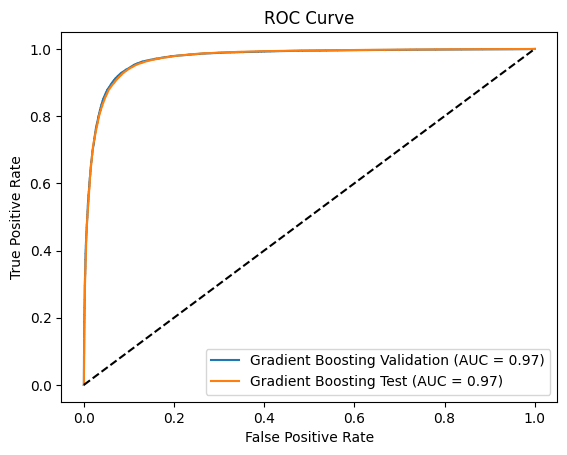

In [6]:
df_main = pd.read_csv('df_clean_high_ed.csv')

df_main= df_main.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

df_withdraws=df_main.copy()

del df_withdraws['result_aprueba']

df_pass=df_main.copy()

df_pass=df_pass[df_pass['result_stays']==1]

del df_pass['result_stays']

df_pass.result_aprueba.value_counts()

df_withdraws.result_stays.value_counts()

# Separar las variables de entrada y la variable de salida
X_large = df_withdraws.loc[:, df_withdraws.columns != 'result_stays']
y_large = df_withdraws.result_stays

# Split the data into training and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_large, y_large, test_size=0.2, random_state=42)
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

gb_clf = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.1, 1],
    'gb__max_depth': [3, 5, 7],
    'gb__n_estimators': [50, 100, 200],
    'gb__max_features': ['sqrt', 'log2']
}
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', gb_clf)
])
gb_grid_search = GridSearchCV(gb_pipeline, param_grid_gb, cv=2, n_jobs=-1, scoring=scoring, refit='roc_auc')
gb_grid_search.fit(X_train, y_train)

# Print the best parameters and score found during the search for each classifier
print("Gradient Boosting - Best parameters:", gb_grid_search.best_params_)
print("Gradient Boosting - Best score:", gb_grid_search.best_score_)
gb_best_model = gb_grid_search.best_estimator_
gb_val_score = gb_best_model.score(X_val, y_val)
print("Gradient Boosting - Validation score:", gb_val_score)

# Get other evaluation metrics for the best model
gb_val_preds = gb_best_model.predict(X_val)
gb_test_preds = gb_best_model.predict(X_test)
gb_val_accuracy = accuracy_score(y_val, gb_val_preds)
gb_test_accuracy = accuracy_score(y_test, gb_test_preds)
gb_val_auc = roc_auc_score(y_val, gb_val_preds)
gb_test_auc = roc_auc_score(y_test, gb_test_preds)
gb_val_f1 = f1_score(y_val, gb_val_preds)
gb_test_f1 = f1_score(y_test, gb_test_preds)
gb_val_recall = recall_score(y_val, gb_val_preds)
gb_test_recall = recall_score(y_test, gb_test_preds)
gb_val_precision = precision_score(y_val, gb_val_preds)
gb_test_precision = precision_score(y_test, gb_test_preds)
print("Gradient Boosting - Validation Accuracy:", gb_val_accuracy)
print("Gradient Boosting - Test Accuracy:", gb_test_accuracy)
print("Gradient Boosting - Validation AUC:", gb_val_auc)
print("Gradient Boosting - Test AUC:", gb_test_auc)
print("Gradient Boosting - Validation F1:", gb_val_f1)
print("Gradient Boosting - Test F1:", gb_test_f1)
print("Gradient Boosting - Validation Recall:", gb_val_recall)
print("Gradient Boosting - Test Recall:", gb_test_recall)
print("Gradient Boosting - Validation Precision:", gb_val_precision)
print("Gradient Boosting - Test Precision:", gb_test_precision)

# Compute ROC curve and AUC
gb_val_probs = gb_best_model.predict_proba(X_val)[:, 1]
gb_test_probs = gb_best_model.predict_proba(X_test)[:, 1]
gb_val_fpr, gb_val_tpr, _ = roc_curve(y_val, gb_val_probs)
gb_test_fpr, gb_test_tpr, _ = roc_curve(y_test, gb_test_probs)
gb_val_auc = auc(gb_val_fpr, gb_val_tpr)
gb_test_auc = auc(gb_test_fpr, gb_test_tpr)
# Plot ROC curve
plt.plot(gb_val_fpr, gb_val_tpr, label="Gradient Boosting Validation (AUC = {:.2f})".format(gb_val_auc))
plt.plot(gb_test_fpr, gb_test_tpr, label="Gradient Boosting Test (AUC = {:.2f})".format(gb_test_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


LOW BAND

Gradient Boosting - Best parameters: {'gb__learning_rate': 1, 'gb__max_depth': 7, 'gb__max_features': 'sqrt', 'gb__n_estimators': 200}
Gradient Boosting - Best score: 0.918036801727256
Gradient Boosting - Validation score: 0.9406290825042709
Gradient Boosting - Validation Accuracy: 0.9406290825042709
Gradient Boosting - Test Accuracy: 0.9414252178666752
Gradient Boosting - Validation AUC: 0.9378273267502772
Gradient Boosting - Test AUC: 0.9384458898082183
Gradient Boosting - Validation F1: 0.9495663456941884
Gradient Boosting - Test F1: 0.9503698758906313
Gradient Boosting - Validation Recall: 0.9541602333161777
Gradient Boosting - Test Recall: 0.9555902578011561
Gradient Boosting - Validation Precision: 0.9450164814626024
Gradient Boosting - Test Precision: 0.9452062218849927


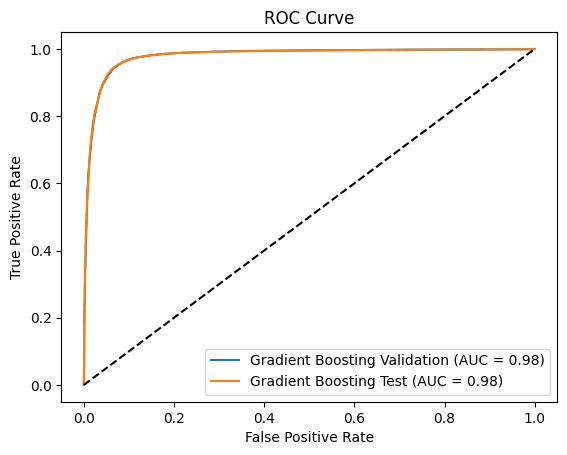

In [8]:
df_main = pd.read_csv('df_clean_low_band.csv')

df_main= df_main.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

df_withdraws=df_main.copy()

del df_withdraws['result_aprueba']

df_pass=df_main.copy()

df_pass=df_pass[df_pass['result_stays']==1]

del df_pass['result_stays']

df_pass.result_aprueba.value_counts()

df_withdraws.result_stays.value_counts()

# Separar las variables de entrada y la variable de salida
X_large = df_withdraws.loc[:, df_withdraws.columns != 'result_stays']
y_large = df_withdraws.result_stays

# Split the data into training and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_large, y_large, test_size=0.2, random_state=42)
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

gb_clf = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.1, 1],
    'gb__max_depth': [3, 5, 7],
    'gb__n_estimators': [50, 100, 200],
    'gb__max_features': ['sqrt', 'log2']
}
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', gb_clf)
])
gb_grid_search = GridSearchCV(gb_pipeline, param_grid_gb, cv=2, n_jobs=-1, scoring=scoring, refit='roc_auc')
gb_grid_search.fit(X_train, y_train)

# Print the best parameters and score found during the search for each classifier
print("Gradient Boosting - Best parameters:", gb_grid_search.best_params_)
print("Gradient Boosting - Best score:", gb_grid_search.best_score_)
gb_best_model = gb_grid_search.best_estimator_
gb_val_score = gb_best_model.score(X_val, y_val)
print("Gradient Boosting - Validation score:", gb_val_score)

# Get other evaluation metrics for the best model
gb_val_preds = gb_best_model.predict(X_val)
gb_test_preds = gb_best_model.predict(X_test)
gb_val_accuracy = accuracy_score(y_val, gb_val_preds)
gb_test_accuracy = accuracy_score(y_test, gb_test_preds)
gb_val_auc = roc_auc_score(y_val, gb_val_preds)
gb_test_auc = roc_auc_score(y_test, gb_test_preds)
gb_val_f1 = f1_score(y_val, gb_val_preds)
gb_test_f1 = f1_score(y_test, gb_test_preds)
gb_val_recall = recall_score(y_val, gb_val_preds)
gb_test_recall = recall_score(y_test, gb_test_preds)
gb_val_precision = precision_score(y_val, gb_val_preds)
gb_test_precision = precision_score(y_test, gb_test_preds)
print("Gradient Boosting - Validation Accuracy:", gb_val_accuracy)
print("Gradient Boosting - Test Accuracy:", gb_test_accuracy)
print("Gradient Boosting - Validation AUC:", gb_val_auc)
print("Gradient Boosting - Test AUC:", gb_test_auc)
print("Gradient Boosting - Validation F1:", gb_val_f1)
print("Gradient Boosting - Test F1:", gb_test_f1)
print("Gradient Boosting - Validation Recall:", gb_val_recall)
print("Gradient Boosting - Test Recall:", gb_test_recall)
print("Gradient Boosting - Validation Precision:", gb_val_precision)
print("Gradient Boosting - Test Precision:", gb_test_precision)

# Compute ROC curve and AUC
gb_val_probs = gb_best_model.predict_proba(X_val)[:, 1]
gb_test_probs = gb_best_model.predict_proba(X_test)[:, 1]
gb_val_fpr, gb_val_tpr, _ = roc_curve(y_val, gb_val_probs)
gb_test_fpr, gb_test_tpr, _ = roc_curve(y_test, gb_test_probs)
gb_val_auc = auc(gb_val_fpr, gb_val_tpr)
gb_test_auc = auc(gb_test_fpr, gb_test_tpr)
# Plot ROC curve
plt.plot(gb_val_fpr, gb_val_tpr, label="Gradient Boosting Validation (AUC = {:.2f})".format(gb_val_auc))
plt.plot(gb_test_fpr, gb_test_tpr, label="Gradient Boosting Test (AUC = {:.2f})".format(gb_test_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


HIGH BAND

Gradient Boosting - Best parameters: {'gb__learning_rate': 1, 'gb__max_depth': 7, 'gb__max_features': 'sqrt', 'gb__n_estimators': 200}
Gradient Boosting - Best score: 0.9015852851567481
Gradient Boosting - Validation score: 0.9364359712556389
Gradient Boosting - Validation Accuracy: 0.9364359712556389
Gradient Boosting - Test Accuracy: 0.9345145261325306
Gradient Boosting - Validation AUC: 0.9311673980389229
Gradient Boosting - Test AUC: 0.9290341210364915
Gradient Boosting - Validation F1: 0.9479970326409495
Gradient Boosting - Test F1: 0.9465029111542393
Gradient Boosting - Validation Recall: 0.9560110720430912
Gradient Boosting - Test Recall: 0.9546921697549312
Gradient Boosting - Validation Precision: 0.9401162362980946
Gradient Boosting - Test Precision: 0.9384529510267634


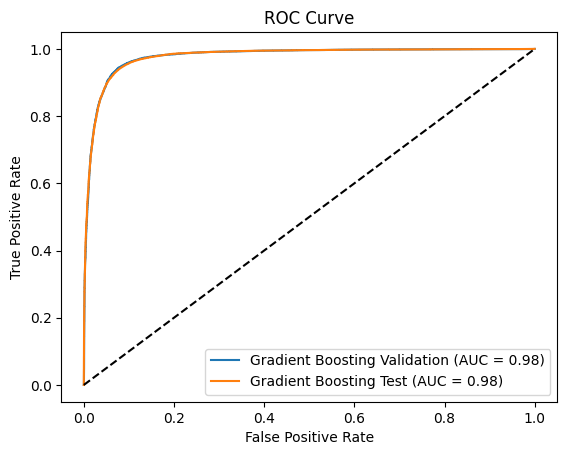

In [9]:
df_main = pd.read_csv('df_clean_high_band.csv')

df_main= df_main.drop(['Unnamed: 0', 'Unnamed: 0.1',	'Unnamed: 0.2' , 'id_student', 'date_unregistration', 'clicks_from_externalquiz', 'clicks_from_oucollaborate', 'clicks_from_page', 'clicks_from_ouelluminate', 'clicks_from_dualpane', 'clicks_from_folder', 'clicks_from_htmlactivity',	'clicks_from_sharedsubpage',	'clicks_from_repeatactivity'], axis='columns')

df_withdraws=df_main.copy()

del df_withdraws['result_aprueba']

df_pass=df_main.copy()

df_pass=df_pass[df_pass['result_stays']==1]

del df_pass['result_stays']

df_pass.result_aprueba.value_counts()

df_withdraws.result_stays.value_counts()

# Separar las variables de entrada y la variable de salida
X_large = df_withdraws.loc[:, df_withdraws.columns != 'result_stays']
y_large = df_withdraws.result_stays

# Split the data into training and test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X_large, y_large, test_size=0.2, random_state=42)
# Split the training set into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, random_state=42)

gb_clf = GradientBoostingClassifier(random_state=42)
param_grid_gb = {
    'gb__learning_rate': [0.01, 0.1, 1],
    'gb__max_depth': [3, 5, 7],
    'gb__n_estimators': [50, 100, 200],
    'gb__max_features': ['sqrt', 'log2']
}
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', gb_clf)
])
gb_grid_search = GridSearchCV(gb_pipeline, param_grid_gb, cv=2, n_jobs=-1, scoring=scoring, refit='roc_auc')
gb_grid_search.fit(X_train, y_train)

# Print the best parameters and score found during the search for each classifier
print("Gradient Boosting - Best parameters:", gb_grid_search.best_params_)
print("Gradient Boosting - Best score:", gb_grid_search.best_score_)
gb_best_model = gb_grid_search.best_estimator_
gb_val_score = gb_best_model.score(X_val, y_val)
print("Gradient Boosting - Validation score:", gb_val_score)

# Get other evaluation metrics for the best model
gb_val_preds = gb_best_model.predict(X_val)
gb_test_preds = gb_best_model.predict(X_test)
gb_val_accuracy = accuracy_score(y_val, gb_val_preds)
gb_test_accuracy = accuracy_score(y_test, gb_test_preds)
gb_val_auc = roc_auc_score(y_val, gb_val_preds)
gb_test_auc = roc_auc_score(y_test, gb_test_preds)
gb_val_f1 = f1_score(y_val, gb_val_preds)
gb_test_f1 = f1_score(y_test, gb_test_preds)
gb_val_recall = recall_score(y_val, gb_val_preds)
gb_test_recall = recall_score(y_test, gb_test_preds)
gb_val_precision = precision_score(y_val, gb_val_preds)
gb_test_precision = precision_score(y_test, gb_test_preds)
print("Gradient Boosting - Validation Accuracy:", gb_val_accuracy)
print("Gradient Boosting - Test Accuracy:", gb_test_accuracy)
print("Gradient Boosting - Validation AUC:", gb_val_auc)
print("Gradient Boosting - Test AUC:", gb_test_auc)
print("Gradient Boosting - Validation F1:", gb_val_f1)
print("Gradient Boosting - Test F1:", gb_test_f1)
print("Gradient Boosting - Validation Recall:", gb_val_recall)
print("Gradient Boosting - Test Recall:", gb_test_recall)
print("Gradient Boosting - Validation Precision:", gb_val_precision)
print("Gradient Boosting - Test Precision:", gb_test_precision)

# Compute ROC curve and AUC
gb_val_probs = gb_best_model.predict_proba(X_val)[:, 1]
gb_test_probs = gb_best_model.predict_proba(X_test)[:, 1]
gb_val_fpr, gb_val_tpr, _ = roc_curve(y_val, gb_val_probs)
gb_test_fpr, gb_test_tpr, _ = roc_curve(y_test, gb_test_probs)
gb_val_auc = auc(gb_val_fpr, gb_val_tpr)
gb_test_auc = auc(gb_test_fpr, gb_test_tpr)
# Plot ROC curve
plt.plot(gb_val_fpr, gb_val_tpr, label="Gradient Boosting Validation (AUC = {:.2f})".format(gb_val_auc))
plt.plot(gb_test_fpr, gb_test_tpr, label="Gradient Boosting Test (AUC = {:.2f})".format(gb_test_auc))
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
